# Autoregressive (AR) and ARMA Processes

At each time step a fresh random **shock** arrives. An autoregressive process feeds its own
past back into itself: today is a fraction of yesterday, plus today's shock.

$$X[n] = \text{mean} + \phi_1\,(X[n-1] - \text{mean}) + \dots + \varepsilon[n]$$

Think of temperature. Today is mostly like yesterday, nudged by random weather. If yesterday
was hot, today probably is too.

Because the process feeds back into itself, **a single shock never fully disappears** -- it
echoes forever, shrinking geometrically each step. That is the opposite of a
[moving-average process](ma_process_demo.ipynb), whose memory stops dead after a fixed
number of steps, and it is why the two are usually taught as a pair.

In [1]:
from symbulate import *

## Create a process and draw a path

`coefs` holds one weight per previous value, so its length is the order $p$. Here is an
AR(1): 70% of yesterday carries over into today.

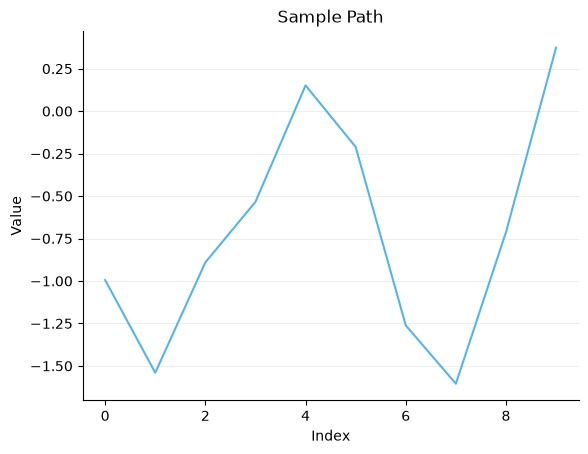

In [2]:
X = AR(coefs=[0.7])
X.sim(1).plot()

## Simulate and plot sample paths

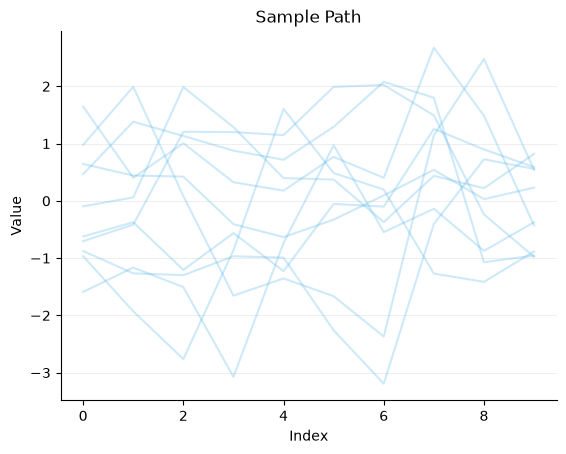

In [3]:
X.sim(10).plot()

## How persistent the process is

The coefficient controls how much of the past carries over. A small value forgets almost
immediately; a large one wanders in long, slow swings.

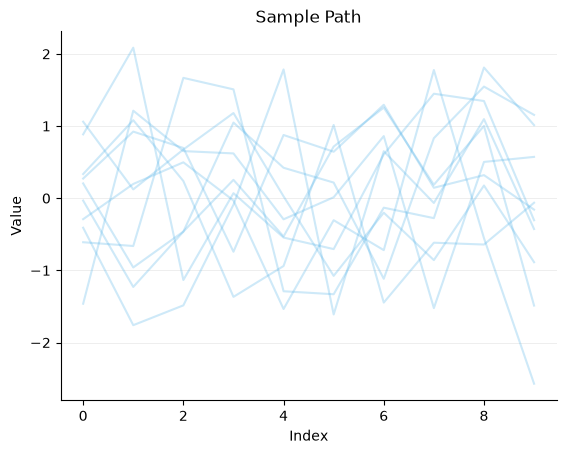

In [4]:
AR(coefs=[0.2]).sim(10).plot()

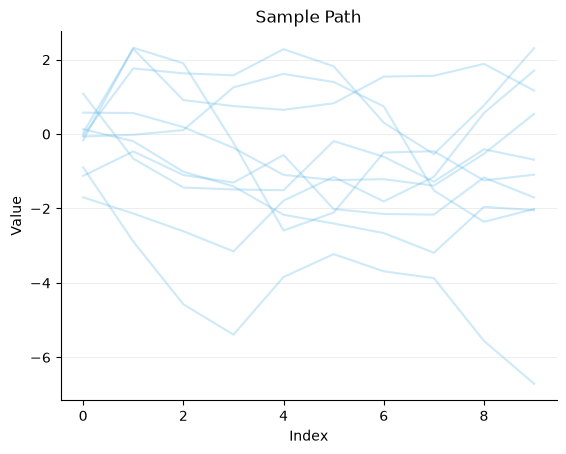

In [5]:
AR(coefs=[0.95]).sim(10).plot()

A negative coefficient makes the process oscillate instead, flipping above and below the
mean from one step to the next.

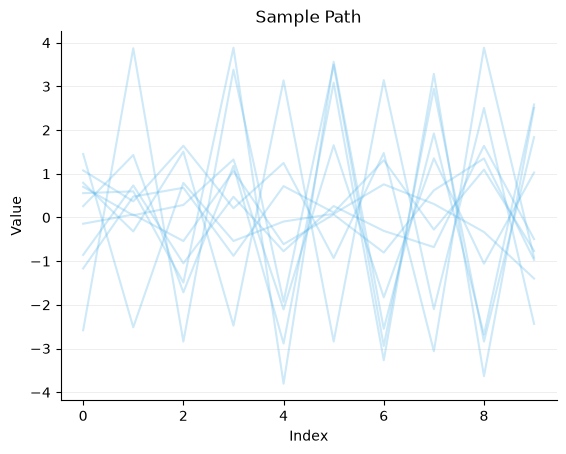

In [6]:
AR(coefs=[-0.8]).sim(10).plot()

## At a coefficient of 1 it becomes a random walk

With nothing pulling it back, the process never settles down -- it just wanders. That is
exactly a `RandomWalk`, and it is the boundary case where an AR stops being stationary.

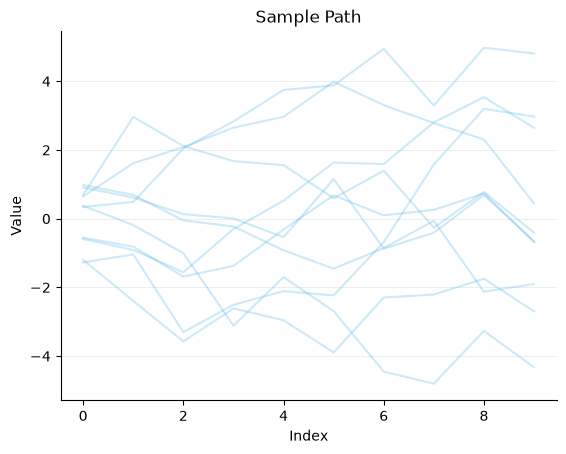

In [7]:
AR(coefs=[1.0]).sim(10).plot()

## The value at a fixed time

Simulating... [██████████████████████████████] 10000/10000 (100%)


Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


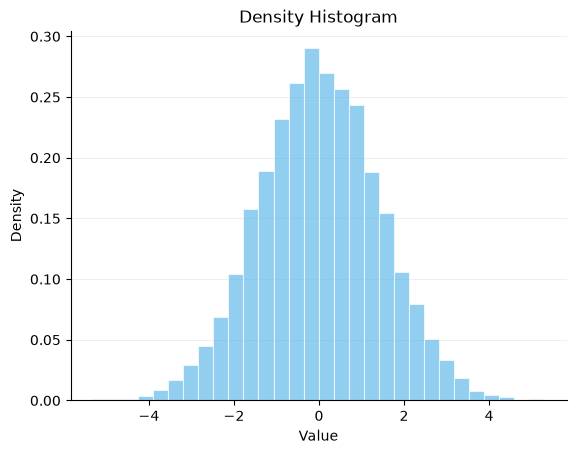

In [8]:
X[30].sim(10000).plot()

For a stationary AR(1) the variance settles at $1/(1 - \phi^2)$, which for $\phi = 0.7$ is
about 1.96.

In [9]:
X[30].sim(10000).var()

Simulating... [██████████████████████████████] 10000/10000 (100%)


1.9730019612863336

## The fingerprint: correlation that fades but never vanishes

For an AR(1) the correlation between values $k$ steps apart is exactly $\phi^k$. Compare
this with the [moving-average process](ma_process_demo.ipynb), where the correlation drops
to exactly zero past its order -- a cliff rather than a slope. That contrast is how you tell
from data which model you want.

In [ ]:
for lag in [1, 2, 3, 4]:
    measured = (X[30] & X[30 + lag]).sim(10000).corr()
    print("lag", lag, " correlation", round(measured, 3), " theory", round(0.7**lag, 3))

Simulating... [██████████████████████████████] 10000/10000 (100%)


lag 1  correlation 0.708  theory 0.7


Simulating... [██████████████████████████████] 10000/10000 (100%)


lag 2  correlation 0.486  theory 0.49


Simulating... [█████████████████████████░░░░░] 8600/10000 (86%)

## Where the process starts

By default every path starts at 0, which leaves a **transient**: the stretch where the
process is still travelling from where it started toward its long-run behaviour. Starting
far from the mean makes the pull home obvious.

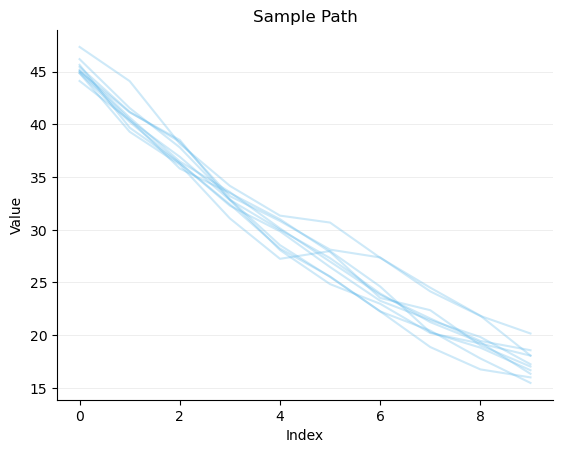

In [ ]:
AR(coefs=[0.9], initial=50).sim(10).plot()

The transient shows up in the numbers too. At time 0 the process has only had one shock, so
its variance is just 1, and it takes a while to climb to the long-run 1.96.

In [ ]:
for n in [0, 1, 2, 5, 30]:
    print("n =", n, " variance", round(AR(coefs=[0.7])[n].sim(10000).var(), 2))

n = 0  variance 1.0


n = 1  variance 1.48


n = 2  variance 1.73


n = 5  variance 1.95



Simulating... [█████████████████████░░░░░░░░░] 7297/10000 (72%)

...


Simulating... [█████████████████████████████░] 9800/10000 (98%)


Simulating... [█████████████████████████████░] 9900/10000 (99%)


Simulating... [██████████████████████████████] 10000/10000 (100%)


Simulating... [██████████████████████████████] 10000/10000 (100%)

n = 30  variance 1.95


## Starting from the long-run distribution

Passing `initial="stationary"` draws the starting value from the process's own long-run
distribution, so there is no transient at all -- the variance is already right at time 0.
Symbulate works this out by solving the Yule-Walker equations for you.

In [ ]:
S = AR(coefs=[0.7], initial="stationary")

for n in [0, 1, 2, 5, 30]:
    print("n =", n, " variance", round(S[n].sim(10000).var(), 2))

n = 0  variance 1.94


n = 1  variance 1.96


n = 2  variance 1.98


n = 5  variance 1.97



Simulating... [███████████████░░░░░░░░░░░░░░░] 5162/10000 (51%)

...


Simulating... [█████████████████████████████░] 9800/10000 (98%)


Simulating... [█████████████████████████████░] 9900/10000 (99%)


Simulating... [██████████████████████████████] 10000/10000 (100%)


Simulating... [██████████████████████████████] 10000/10000 (100%)

n = 30  variance 1.97


Which one you want depends on the question. Use the default when the starting point is part
of the story -- "the stock was at 50 yesterday, what happens next" -- and `"stationary"` when
you want the process's typical behaviour without a warm-up period contaminating it.

`"stationary"` is available for a pure autoregressive process with normal shocks whose
coefficients settle down. Outside that, there is no long-run distribution to draw from, and
Symbulate says so rather than guessing:

- with moving-average terms, the long-run distribution has no simple closed form;
- with non-normal shocks, there is no closed form at all;
- with a coefficient of 1 or more, the process never settles, so nothing exists to start from.

## Higher orders

An AR(2) looks back two steps. The stationary start handles the fact that those two starting
values are *correlated with each other*, which a single number could not express.

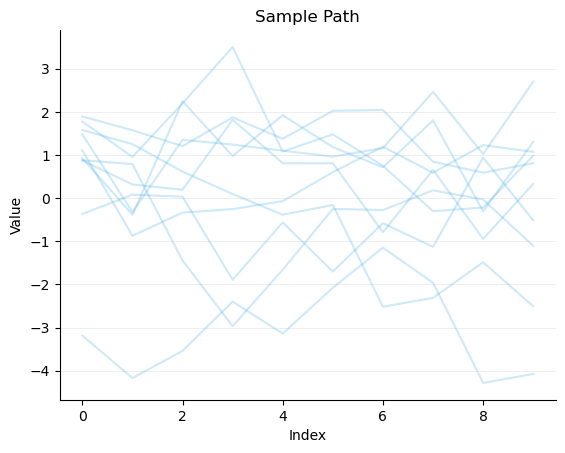

In [ ]:
AR(coefs=[0.5, 0.3], initial="stationary").sim(10).plot()

## Combining both kinds of memory: ARMA

Real series often have a little of each -- persistent feedback *and* a short-lived shock
echo. `ARMA` takes both sets of coefficients, and needs fewer parameters than forcing either
one alone to fit.

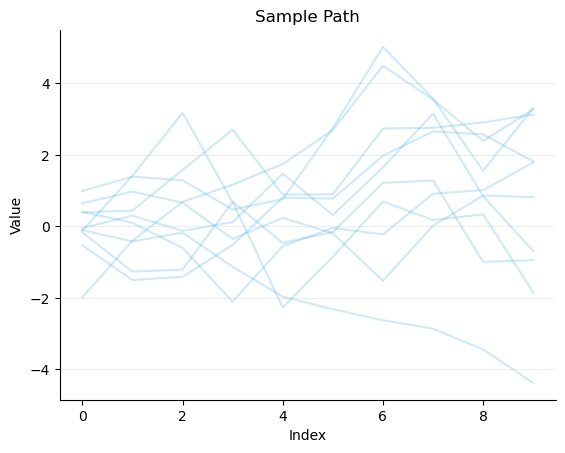

In [ ]:
ARMA(ar_coefs=[0.6], ma_coefs=[0.4]).sim(10).plot()

Leaving one side empty recovers the pure cases: `ARMA(ar_coefs=[...])` is an `AR`, and
`ARMA(ar_coefs=[], ma_coefs=[...])` is an `MA`.

In [ ]:
W = ARMA(ar_coefs=[], ma_coefs=[0.8, 0.5])
W[10].sim(10000).var()   # matches MA(coefs=[0.8, 0.5]): 1 + 0.8**2 + 0.5**2 = 1.89

1.8882816729940248